In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data_path=r'C:\Users\USER\Downloads\DataScience-Certificate\titanic-survival-prediction\data\train.csv'

df=pd.read_csv(data_path)


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.shape

(891, 12)

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [46]:
print(f"Null Values: \n {df.isnull().sum()}")
df['Age'].isnull().sum()

Null Values: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


np.int64(177)

In [47]:
#Drop Cabin Column as null values is significantly high
df=df.drop(columns=['Cabin'])


In [48]:
#Replacing the 'Age' column null values with median
# df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age']=df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_18468\665109044.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age']=df['Age'].fillna(df['Age'].median(), inplace=True)


In [49]:
#Replacing 'Embarked' column null values with mode
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


C:\Users\USER\AppData\Local\Temp\ipykernel_18468\4055243224.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [50]:
#Quantify Missing Values Using Percentages for documentation
missing_percentage=(df.isnull().sum()/ len(df)) *100

missing_percentage.sort_values(ascending=False)



PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

## Missing Value Observations

- Cabin has over 77% missing values and will likely be dropped.(Already Dropped Earlier)
- Age has moderate missing values and will be imputed using the median.
- Embarked has only 2 missing values and can be filled using the mode.

In [51]:
##Identifying categorical columns
#NB:Machine learning models cannot directly interpret text categories.(e.g Male,Female must become numbers)
#Encoding Needed

df.select_dtypes(include='object').columns


C:\Users\USER\AppData\Local\Temp\ipykernel_18468\2080506558.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [52]:
##Encoding Sex
#Binary Encoding for we only have two options

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [53]:
df['Embarked'].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [58]:
# df['Embarked']=df['Embarked'].map({'S' :0, 'C':1, 'Q':2})

##One hot encoding
#Drop first to avoid dummy variable trap (multicollinearity)

df=pd.get_dummies(df, columns=['Embarked'], drop_first=True)






By using drop_first=True, we intentionally deleted the first category ('C') to avoid redundant data. Here is how to read the data now:
**Embarked_Q**  **Embarked_S**   **The Reality**
False             False            The passenger boarded at C (Cherbourg)
False             True             The passenger boarded at S (Southampton)
True              False            The passenger boarded at Q (Queenstown)

In [55]:
#Lets drop the unecessary columns not necessary for Machine Learning()
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)


**Core Principle**

A feature (column) is useful if it helps the model:

identify patterns,
reduce uncertainty,
improve predictions.

A column is often removed when:

it contains little signal,
too much noise,
too many unique values,
leakage,
redundancy,
impracticality.

**Think of Features as Information Sources**

**Every column asks:**

Does this feature help predict the target variable?

For Titanic:

**Target:**

Survived

**So for every column, ask:**

Can this help predict survival?

In [44]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,NaN,22.0,1,0,7.2500,S
1,1,1,NaN,38.0,1,0,71.2833,C
2,1,3,NaN,26.0,0,0,7.9250,S
3,1,1,NaN,35.0,1,0,53.1000,S
4,0,3,NaN,35.0,0,0,8.0500,S


In [64]:
##Machine Learning Pipeline
#Separating features(x) and target(y) (x is input, y is output)

x=df.drop('Survived',axis=1)
y=df['Survived']

#Verify the shape of x and y
print(x.shape)
print(y.shape)

(891, 8)
(891,)


Model Accuracy: 0.8100558659217877
[[90 15]
 [19 55]]


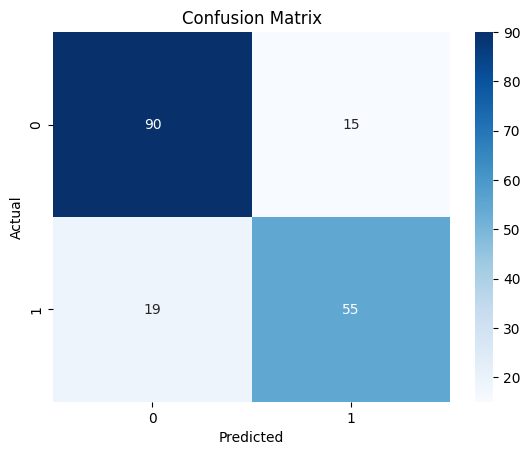

In [65]:
##Train / Test Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

#Split Dataset
#test_size=02 means 20% of the data will be used for testing and 80% for training.
#random_state=42 is set to ensure reproducibility of results. It ensures that the same random split is obtained each time the code is run.
X_train, X_test, y_train, y_test =train_test_split(x,y,test_size=0.2,random_state=42)


#create a model
#max_iter is set to 1000 to ensure convergence so increase the number of iterations for the optimization algorithm to converge.
#Increasing iterations helps: 1).Training Stability and 2). Converge reliability
model=LogisticRegression(max_iter=1000)    

#Training Model
model.fit(X_train, y_train)
#Make Predictions
y_pred =model.predict(X_test)


#Evaluate Accuracy
accuracy = accuracy_score(y_test,y_pred)

print(f"Model Accuracy: {accuracy}")

#Evaluate Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Model Evaluation and Interpretation

The Logistic Regression model was trained to predict whether a passenger survived the Titanic disaster based on features such as passenger class, gender, age, fare, and embarkation point.

The dataset was first preprocessed by:

- handling missing values,
- encoding categorical variables,
- and removing unnecessary columns.

The data was then divided into training and testing datasets to evaluate the model on unseen data.

---

## Model Performance

The model achieved a reasonable prediction accuracy on the test dataset, indicating that the selected features contain meaningful patterns related to passenger survival.

A confusion matrix was used to evaluate the model's predictions in more detail.

### Confusion Matrix Interpretation

| Actual / Predicted | Did Not Survive (0) | Survived (1) |
|---|---|---|
| Did Not Survive (0) | 90 | 15 |
| Survived (1) | 19 | 55 |

### Interpretation

- **90 True Negatives:**  
  The model correctly predicted passengers who did not survive.

- **55 True Positives:**  
  The model correctly predicted passengers who survived.

- **15 False Positives:**  
  The model predicted survival for passengers who actually did not survive.

- **19 False Negatives:**  
  The model predicted that some passengers did not survive when they actually survived.

---

## Key Insights

The results suggest that features such as:

- gender,
- passenger class,
- fare,
- and age

have predictive relationships with survival outcomes.

The project demonstrates a complete machine learning workflow including:

1. Data loading
2. Exploratory Data Analysis (EDA)
3. Data preprocessing
4. Feature engineering
5. Model training
6. Prediction
7. Model evaluation

This workflow reflects the foundational steps commonly used in real-world machine learning and predictive analytics projects.